In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, LogisticRegression, SGDRegressor
from sklearn.metrics import mean_squared_error, log_loss, accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler

## Question 1: Linear Regression with Gradient Descent (Mother-Daughter Heights)

In [11]:
df = pd.read_csv('mother_and_daughter.csv')
X = df['mother_height'].values.reshape(-1, 1)
y = df['daughter_height'].values

X_b = np.c_[np.ones((len(X), 1)), X]

def linear_gd(X_b, y, lr=0.0001, epochs=4, batch_size=None):
    m = len(y)
    theta = np.zeros(X_b.shape[1])
    history = []
    n_iter = 0
    for epoch in range(epochs):
        if batch_size is None:
            indices = np.arange(m)
            np.random.shuffle(indices)
            for i in indices:
                xi = X_b[i:i+1]
                yi = y[i:i+1]
                pred = xi.dot(theta)
                error = pred - yi
                gradients = xi.T.dot(error)
                theta = theta - lr * gradients.flatten()
                mse = np.mean((X_b.dot(theta) - y) ** 2)
                history.append(mse)
                n_iter += 1
        else:
            for i in range(0, m, batch_size):
                xi = X_b[i:i+batch_size]
                yi = y[i:i+batch_size]
                pred = xi.dot(theta)
                error = pred - yi
                gradients = (2/len(yi)) * xi.T.dot(error)
                theta = theta - lr * gradients.flatten()
                mse = np.mean((X_b.dot(theta) - y) ** 2)
                history.append(mse)
                n_iter += 1
    return theta, history, n_iter

theta_gd, hist_gd, n_iters = linear_gd(X_b, y, lr=0.0001, epochs=4)
print('GD coefficients (intercept, slope):', theta_gd)
print('Total iterations:', n_iters)

GD coefficients (intercept, slope): [0.01493623 0.97150136]
Total iterations: 24


In [12]:
sk_model = LinearRegression()
sk_model.fit(X, y)
print('sklearn intercept:', sk_model.intercept_)
print('sklearn slope:', sk_model.coef_[0])

y_pred_gd = X_b.dot(theta_gd)
y_pred_sk = sk_model.predict(X)

mse_gd = mean_squared_error(y, y_pred_gd)
rmse_gd = np.sqrt(mse_gd)
print('GD  MSE:', mse_gd, ' RMSE:', rmse_gd)

mse_sk = mean_squared_error(y, y_pred_sk)
rmse_sk = np.sqrt(mse_sk)
print('SK  MSE:', mse_sk, ' RMSE:', rmse_sk)

try:
    ll = log_loss(y > np.median(y), 1/(1+np.exp(-(y_pred_gd - np.mean(y_pred_gd)))))
    print('Approx log loss (binarized):', ll)
except Exception as e:
    print('log loss skipped (regression task)')

sklearn intercept: -12.9794520547945
sklearn slope: 1.198630136986301
GD  MSE: 9.901967363448568  RMSE: 3.146739163554642
SK  MSE: 6.915525114155261  RMSE: 2.6297386018681137
Approx log loss (binarized): 0.22693589687850882


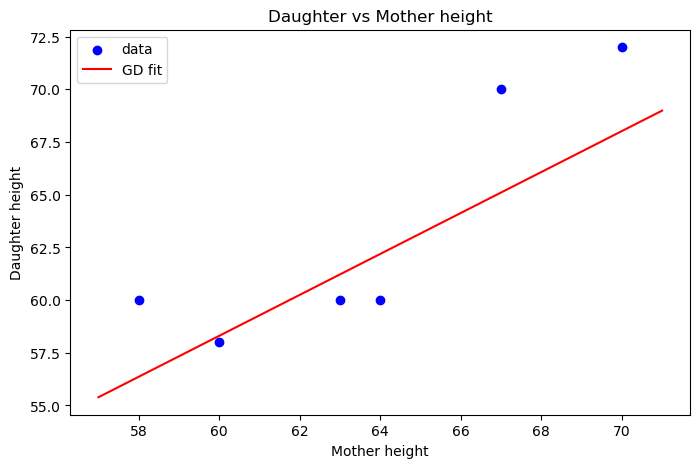

Predicted daughter height for mother=63: 61.21952162629746


In [13]:
plt.figure(figsize=(8,5))
plt.scatter(X, y, color='blue', label='data')
x_line = np.linspace(X.min()-1, X.max()+1, 100).reshape(-1,1)
x_line_b = np.c_[np.ones((100,1)), x_line]
plt.plot(x_line, x_line_b.dot(theta_gd), color='red', label='GD fit')
plt.xlabel('Mother height')
plt.ylabel('Daughter height')
plt.legend()
plt.title('Daughter vs Mother height')
plt.show()

pred_63 = np.array([1, 63]).dot(theta_gd)
print('Predicted daughter height for mother=63:', pred_63)

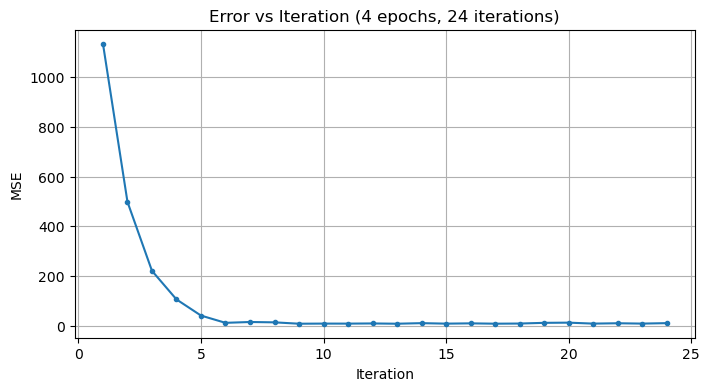

In [14]:
plt.figure(figsize=(8,4))
plt.plot(range(1, len(hist_gd)+1), hist_gd, marker='o', markersize=3)
plt.xlabel('Iteration')
plt.ylabel('MSE')
plt.title('Error vs Iteration (4 epochs, 24 iterations)')
plt.grid(True)
plt.show()

## Question 2: Logistic Regression with Gradient Descent (Hours Study vs Pass/Fail)

In [15]:
data2 = {
    'hours': [1,2,3,4,5,6,7,8],
    'pass': [0,0,0,0,1,1,1,1]
}
df2 = pd.DataFrame(data2)
df2.to_csv('study_pass.csv', index=False)
print(df2)

   hours  pass
0      1     0
1      2     0
2      3     0
3      4     0
4      5     1
5      6     1
6      7     1
7      8     1


In [33]:
df2 = pd.read_csv('study_pass.csv')
X2 = df2['hours'].values.reshape(-1, 1)
y2 = df2['pass'].values.astype(float)

X2_b = np.c_[np.ones((len(X2), 1)), X2]

def sigmoid(z):
    return 1 / (1 + np.exp(-np.clip(z, -500, 500)))

def logistic_gd(X_b, y, lr=0.1, epochs=3):
    m = len(y)
    theta = np.zeros(X_b.shape[1])
    history = []
    n_iter = 0
    for epoch in range(epochs):
        indices = np.arange(m)
        np.random.shuffle(indices)
        for i in indices:
            xi = X_b[i:i+1]
            yi = y[i:i+1]
            pred = sigmoid(xi.dot(theta))
            error = pred - yi
            gradients = xi.T.dot(error).flatten()
            theta = theta - lr * gradients
            p = sigmoid(X_b.dot(theta))
            loss = -np.mean(y * np.log(p + 1e-15) + (1 - y) * np.log(1 - p + 1e-15))
            history.append(loss)
            n_iter += 1
    return theta, history, n_iter

theta_log, hist_log, n_iters2 = logistic_gd(X2_b, y2, lr=0.1, epochs=3)
print('GD logistic coeffs (intercept, slope):', theta_log)
print('Total iterations:', n_iters2)

GD logistic coeffs (intercept, slope): [-0.41277425  0.33190242]
Total iterations: 24


In [34]:
sk_log = LogisticRegression(solver='lbfgs', max_iter=1000)
sk_log.fit(X2, y2)
print('sklearn intercept:', sk_log.intercept_[0])
print('sklearn coef:', sk_log.coef_[0][0])

p_gd = sigmoid(X2_b.dot(theta_log))
y_pred_gd = (p_gd >= 0.5).astype(int)
print('GD predicted probabilities:', p_gd)
print('GD predicted labels:', y_pred_gd)
print('GD accuracy:', accuracy_score(y2, y_pred_gd))

p_sk = sk_log.predict_proba(X2)[:,1]
y_pred_sk = sk_log.predict(X2)
print('sklearn accuracy:', accuracy_score(y2, y_pred_sk))

sklearn intercept: -5.264107913297967
sklearn coef: 1.1697993675705602
GD predicted probabilities: [0.47979305 0.56243015 0.64174201 0.71398862 0.77673466 0.82901186
 0.8710801  0.90399687]
GD predicted labels: [0 1 1 1 1 1 1 1]
GD accuracy: 0.625
sklearn accuracy: 1.0


In [38]:
def predict_prob(hours, theta):
    return sigmoid(np.array([1.0, hours]).dot(theta))

print('P(pass | 3.5 hours) =', predict_prob(3.5, theta_log))
print('P(pass | 7.5 hours) =', predict_prob(7.5, theta_log))
print(predict_prob)

P(pass | 3.5 hours) = 0.6789355269676185
P(pass | 7.5 hours) = 0.8885974287226738
<function predict_prob at 0x7f81fdf3c860>


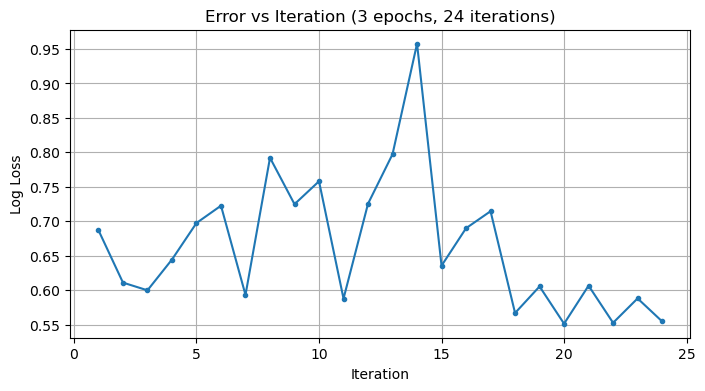

In [39]:
plt.figure(figsize=(8,4))
plt.plot(range(1, len(hist_log)+1), hist_log, marker='o', markersize=3)
plt.xlabel('Iteration')
plt.ylabel('Log Loss')
plt.title('Error vs Iteration (3 epochs, 24 iterations)')
plt.grid(True)
plt.show()

## Question 3: Logistic Regression on given multi-feature data

In [40]:
data3 = {
    'x1': [4, 2, 1, 3, 1, 6],
    'x2': [1, 8, 0, 2, 4, 7],
    'y':  [2, -14, 1, -1, -7, -8]
}
df3 = pd.DataFrame(data3)
print(df3)

# Y is continuous; convert to binary for logistic (positive=1, else=0)
y3_bin = (df3['y'] > 0).astype(int).values
X3 = df3[['x1','x2']].values
X3_b = np.c_[np.ones((len(X3),1)), X3]

theta3, hist3, _ = logistic_gd(X3_b, y3_bin.astype(float), lr=0.1, epochs=50)
print('GD logistic coeffs:', theta3)

sk3 = LogisticRegression(solver='lbfgs', max_iter=1000)
sk3.fit(X3, y3_bin)
print('sklearn intercept:', sk3.intercept_[0], 'coefs:', sk3.coef_[0])

p3 = sigmoid(X3_b.dot(theta3))
pred3 = (p3 >= 0.5).astype(int)
print('GD accuracy:', accuracy_score(y3_bin, pred3))
print('sklearn accuracy:', accuracy_score(y3_bin, sk3.predict(X3)))

   x1  x2   y
0   4   1   2
1   2   8 -14
2   1   0   1
3   3   2  -1
4   1   4  -7
5   6   7  -8
GD logistic coeffs: [ 0.78433781  1.02055152 -2.70812928]
sklearn intercept: 1.3312031022666448 coefs: [ 0.08482852 -0.94472563]
GD accuracy: 1.0
sklearn accuracy: 1.0


## Additional: SGD on synthetic year-gold-silver style data (placeholder)
Replace with real Week-4 table when available.

In [41]:
years = np.arange(1965, 2023)
np.random.seed(42)
gold = 30 + 0.8*(years-1965) + np.random.randn(len(years))*5
silver = 5 + 0.15*(years-1965) + np.random.randn(len(years))*1
df_gs = pd.DataFrame({'year': years, 'gold': gold, 'silver': silver})
df_gs.to_csv('gold_silver.csv', index=False)

Xg = df_gs['year'].values.reshape(-1,1)
yg = df_gs['gold'].values
Xg_b = np.c_[np.ones((len(Xg),1)), Xg]

theta_g, hist_g, _ = linear_gd(Xg_b, yg, lr=1e-8, epochs=5)
print('GD gold coeffs:', theta_g)

sk_g = LinearRegression().fit(Xg, yg)
print('sklearn gold intercept/slope:', sk_g.intercept_, sk_g.coef_[0])

pred_2025 = np.array([1, 2025]).dot(theta_g)
print('Predicted gold 2025 (1g):', pred_2025)

Xs = df_gs['year'].values.reshape(-1,1)
ys = df_gs['silver'].values
Xs_b = np.c_[np.ones((len(Xs),1)), Xs]
theta_s, _, _ = linear_gd(Xs_b, ys, lr=1e-8, epochs=5)
print('Predicted silver 2024 (1g):', np.array([1,2024]).dot(theta_s))
print('Predicted gold 2024 (1g):', np.array([1,2024]).dot(theta_g))

GD gold coeffs: [1.31325205e-05 2.68065572e-02]
sklearn gold intercept/slope: -1505.1019468263667 0.7810330338100161
Predicted gold 2025 (1g): 54.28329148881037
Predicted silver 2024 (1g): 9.778529939299084
Predicted gold 2024 (1g): 54.25648493159739


In [42]:
y_bin_g = (df_gs['gold'] > df_gs['gold'].median()).astype(int).values
sk_log_g = LogisticRegression().fit(Xg, y_bin_g)
print('Logistic on gold (binary): intercept', sk_log_g.intercept_[0], 'coef', sk_log_g.coef_[0][0])
print('Accuracy:', accuracy_score(y_bin_g, sk_log_g.predict(Xg)))

Logistic on gold (binary): intercept -567.4384069432119 coef 0.28464429742353176
Accuracy: 0.9310344827586207


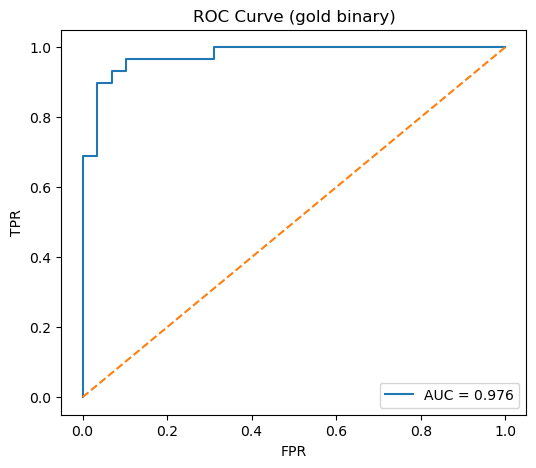

AUC: 0.9762187871581451


In [43]:
from sklearn.metrics import roc_curve, auc
probs = sk_log_g.predict_proba(Xg)[:,1]
fpr, tpr, _ = roc_curve(y_bin_g, probs)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.3f}')
plt.plot([0,1],[0,1],'--')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.title('ROC Curve (gold binary)')
plt.legend()
plt.show()
print('AUC:', roc_auc)